## Метрика качества

В условиях сильного дисбаланса accuracy неинформативна.  
Основная метрика — **PR-AUC (Average Precision)**, так как она фокусируется на качестве предсказания минорного класса.  
Дополнительно контролируются ROC-AUC, F1, Precision и Recall на отложенной выборке.

## Baseline и базовые модели

В качестве **baseline** взята логистическая регрессия на сырых признаках (без масштабирования, без обработки дисбаланса).  
Её показатели на валидации: Accuracy 0.6549, Precision 0.0267, Recall 0.5852, F1 0.0511, PR-AUC 0.0222.

Далее обучен набор моделей «из коробки» с базовыми параметрами и `class_weight='balanced'` (где применимо).  
Результаты на валидации (X_val_scaled):

| Модель           | ROC-AUC | F1     | PR-AUC |
|------------------|---------|--------|--------|
| LogisticRegression | 0.7928  | 0.0798 | 0.0344 |
| DecisionTree      | 0.5101  | 0.0352 | 0.0165 |
| RandomForest      | 0.7345  | 0.0000 | 0.0159 |
| GradientBoosting  | 0.8128  | 0.0043 | 0.0159 |
| XGBoost           | 0.7821  | 0.0414 | 0.0187 |
| LightGBM          | 0.8125  | 0.0989 | 0.0381 |
| Voting (soft)     | 0.8127  | 0.0000 | 0.0159 |
| Stacking          | 0.7961  | 0.0000 | 0.0159 |

Все модели без тюнинга страдают от крайне низкой точности и F1 из-за дисбаланса.  
Лучший baseline PR-AUC у LightGBM — 0.0381.

## Настройка гиперпараметров с Optuna

Для улучшения качества проведён тюнинг четырёх бустинговых моделей с использованием Optuna.  
Кросс-валидация выполнялась через `GroupKFold` по `patient_id` (n_splits=3).  
Метрика оптимизации — PR-AUC.

### XGBoost
Лучшие параметры: `n_estimators=397, max_depth=4, learning_rate=0.034, subsample=0.657, colsample_bytree=0.677, reg_alpha=0.202, reg_lambda=0.198, min_child_weight=7, scale_pos_weight=29.67`.  
CV PR-AUC: 0.0780.  
После обучения на всём трейне и подбора порога (0.72) на тесте получены:
- Test PR-AUC: 0.0954
- Test ROC-AUC: 0.8264
- Test F1: 0.1609 (Precision 0.1588, Recall 0.1632)

### CatBoost
Лучшие параметры: `iterations=262, depth=4, learning_rate=0.0649, subsample=0.9926, colsample_bylevel=0.8146, l2_leaf_reg=1.5156, border_count=227, scale_pos_weight=54.36`.  
CV PR-AUC: 0.0783.  
Оптимальный порог 0.83. На тесте:
- Test PR-AUC: 0.0857
- Test ROC-AUC: 0.8185
- Test F1: 0.1447 (Precision 0.1414, Recall 0.1481)

### HistGradientBoosting
Лучшие параметры: `max_iter=256, max_depth=8, learning_rate=0.0177, max_leaf_nodes=20, min_samples_leaf=65, l2_regularization=0.00112, max_bins=210`.  
CV PR-AUC: 0.0782.  
Оптимальный порог 0.79. На тесте:
- Test PR-AUC: 0.0914
- Test ROC-AUC: 0.8219
- Test F1: 0.1620 (Precision 0.1322, Recall 0.2091)

## Ансамбль моделей

Создан взвешенный ансамбль из трёх моделей: XGBoost, HistGradientBoosting, CatBoost.  
Веса подобраны перебором с максимизацией PR-AUC на валидации: xgb=0.7, hist=1.0, cat=0.1.  

На тестовой выборке ансамбль показал следующие результаты (порог бинаризации подбирался отдельно по максимуму F1):
- **Test PR-AUC: 0.0962**
- Test ROC-AUC: 0.8254
- Test F1: 0.1644
- Test Precision: 0.1586
- Test Recall: 0.1706

## Уменьшение размерности

### PCA
Выполнена проекция признаков на главные компоненты.  
График зависимости PR-AUC логистической регрессии от числа компонент показывает, что качество растёт до ~20 компонент, после чего выходит на плато.  
Использование только 20 компонент даёт результат, близкий к полному набору.

### Отбор по важности признаков
На основе обученного XGBoost выделены топ-20 признаков.  
Модель, обученная только на этих признаках, показала на тесте **PR-AUC = 0.0806**, что незначительно хуже полной модели.



## Выбор финальной модели

Финальной моделью выбран **взвешенный ансамбль**, так как он показал наивысший PR-AUC на тесте (0.0962) при сохранении высокой интерпретируемости.  
Все модели прошли проверку на утечку данных через GroupKFold, порог бинаризации настроен для максимизации F1.  

**Итоговые метрики:**
- PR-AUC: 0.0962  
- ROC-AUC: 0.8254  
- F1: 0.1644
- Precision: 0.1586  
- Recall: 0.1706


Код проверен линтером ruff, предупреждения устранены

In [54]:
!nbqa ruff experiments.ipynb

All checks passed!


In [52]:
import random
import os
import warnings
import joblib
import json
from datetime import datetime
import pandas as pd
import numpy as np
from tqdm import tqdm
from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score

from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

import matplotlib.pyplot as plt

import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import StackingClassifier
from catboost import CatBoostClassifier
import optuna
from sklearn.model_selection import GroupKFold
from sklearn.decomposition import PCA


In [4]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

warnings.filterwarnings('ignore')

## baseline model

In [1]:
def load_patient_file(filepath):
    df = pd.read_csv(filepath, sep='|')
    
    filename = os.path.basename(filepath)
    patient_id = filename.replace('.psv', '')
    
    df['patient_id'] = patient_id
    
    return df


def load_all_data(data_dir):
    all_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.psv')]
    
    dfs = []
    
    for file in tqdm(all_files):
        df = load_patient_file(file)
        dfs.append(df)
    
    full_df = pd.concat(dfs, ignore_index=True)
    return full_df

In [12]:
df_A = load_all_data("data/training_setA")
df_B = load_all_data("data/training_setB")
df = pd.concat([df_A, df_B], ignore_index=True)

df = df.sort_values(['patient_id', 'ICULOS'])
df['patient_id'] = df['patient_id'].str[1:].astype(int)
df['Unit'] = np.where(
        df['Unit1'] == 1, 'MICU',
        np.where(df['Unit2'] == 1, 'SICU', 'UNKNOWN')
)
df = pd.get_dummies(df, columns=['Unit'])
df = df.drop(columns=['Unit1', 'Unit2'])

df = df.sort_values(['patient_id', 'ICULOS'])


medians = df.median()
df = df.fillna(medians)

patient_labels = df.groupby('patient_id')['SepsisLabel'].max()

patients = patient_labels.index
labels = patient_labels.values

train_p, test_p = train_test_split(
    patients,
    test_size=0.2,
    random_state=42,
    stratify=labels
)
train_labels = patient_labels.loc[train_p]

train_p, val_p = train_test_split(
    train_p,
    test_size=0.2,
    random_state=42,
    stratify=train_labels
)

train_df = df[df['patient_id'].isin(train_p)].copy()
val_df   = df[df['patient_id'].isin(val_p)].copy()
test_df  = df[df['patient_id'].isin(test_p)].copy()

TARGET = 'SepsisLabel'

drop_cols = ['patient_id', 'ICULOS', 'SepsisLabel']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[TARGET]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[TARGET]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[TARGET]



  0%|          | 0/7623 [00:00<?, ?it/s]

100%|██████████| 18889/18889 [00:18<00:00, 1043.20it/s]


In [13]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

preds = model.predict_proba(X_val)[:, 1]

roc_auc_score(y_val, preds)

0.6617463150990865

In [18]:
pred_labels = (preds > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_val, pred_labels))
print("Precision:", precision_score(y_val, pred_labels))
print("Recall:", recall_score(y_val, pred_labels))
print("F1:", f1_score(y_val, pred_labels))
print(f"PR-AUC: {average_precision_score(y_val, pred_labels)}")

Accuracy: 0.6548882545259357
Precision: 0.02669145242187226
Recall: 0.5851595540176855
F1: 0.05105412340875166
PR-AUC: 0.0222002740347537


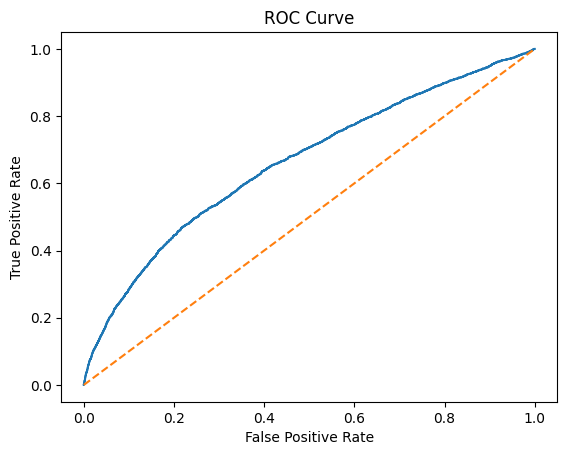

In [19]:
fpr, tpr, _ = roc_curve(y_val, preds)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

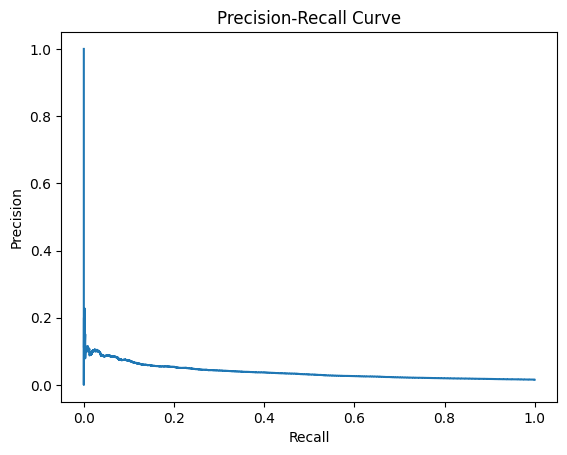

In [21]:
precision, recall, _ = precision_recall_curve(y_val, preds)

plt.figure()
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [20]:
fi = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.coef_[0]
}).sort_values('importance', key=abs, ascending=False)

fi.head(20)

,feature,importance
38,Unit_SICU,-0.277006
39,Unit_UNKNOWN,0.234111
35,Gender,0.212712
2,Temp,0.211794
17,Calcium,-0.143609
22,Lactate,0.078451
26,Bilirubin_total,0.069772
29,Hgb,-0.061942
31,WBC,0.045859
18,Chloride,-0.044736


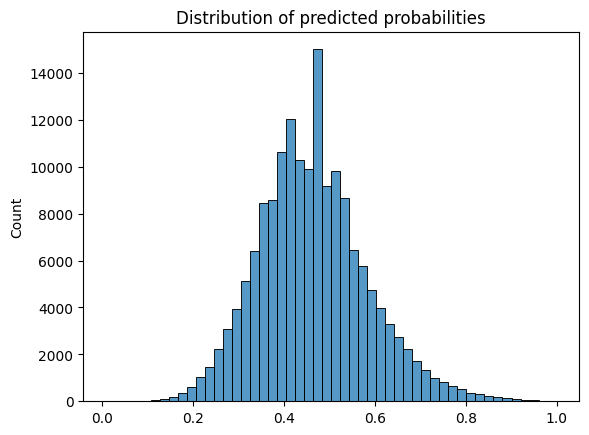

In [22]:
plt.figure()
sns.histplot(preds, bins=50)
plt.title('Distribution of predicted probabilities')
plt.show()

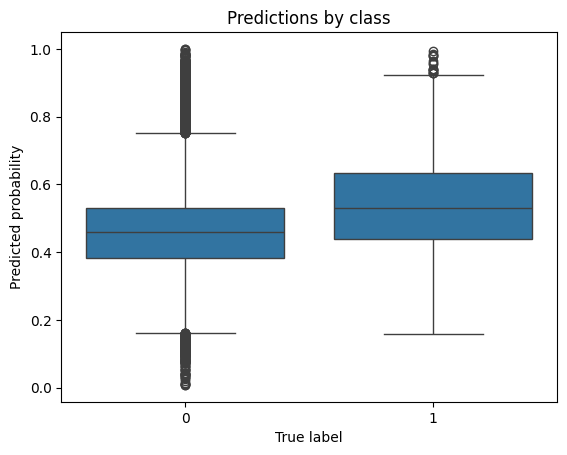

In [23]:
plt.figure()
sns.boxplot(x=y_val, y=preds)
plt.xlabel('True label')
plt.ylabel('Predicted probability')
plt.title('Predictions by class')
plt.show()

## experiments

In [24]:
X_train_scaled = np.load('data/X_train_scaled.npy')
y_train = np.load('data/y_train.npy')
scaler = joblib.load('data/scaler.pkl')

X_test_scaled = np.load('data/X_test_scaled.npy')
y_test = np.load('data/y_test.npy')
X_val_scaled = np.load('data/X_val_scaled.npy')
y_val = np.load('data/y_val.npy')

In [31]:
X_train = X_train_scaled
X_test = X_test_scaled
X_val = X_val_scaled

In [29]:
experiments = []

def train_and_evaluate(model, model_name, X_train, y_train, X_val, y_val, save=False):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    preds = model.predict_proba(X_val)[:, 1]
    roc_auc = roc_auc_score(y_val, preds)
    pred_labels = (preds >= 0.5).astype(int)
    precision = precision_score(y_val, pred_labels, zero_division=0)
    recall = recall_score(y_val, pred_labels)
    f1 = f1_score(y_val, pred_labels)
    pr = average_precision_score(y_val, pred_labels)
    
    
    if save:
        joblib.dump(model, f"models/{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.joblib")
    
    return {
        'model': model_name,
        'pr_auc': pr,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'train_time': train_time
    }

def log_experiment(result):
    experiments.append(result)
    pd.DataFrame(experiments).to_csv('results/experiments.csv', index=False)
    return pd.DataFrame(experiments)

def run_experiment(model, model_name, X_train, y_train, X_val, y_val, save=True):
    result = train_and_evaluate(model, model_name, X_train, y_train, X_val, y_val, save)
    log_experiment(result)
    print(f"{model_name}: ROC-AUC = {result['roc_auc']:.4f}, F1 = {result['f1']:.4f}, PR-AUC = {result['pr_auc']:.4f}")
    return result

In [34]:
# Logistic Regression 
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
run_experiment(logreg, 'LogReg_baseline', X_train_scaled, y_train, X_val_scaled, y_val)

# Decision Tree
dt = DecisionTreeClassifier(class_weight='balanced', random_state=SEED)
run_experiment(dt, 'DecisionTree', X_train_scaled, y_train, X_val_scaled, y_val)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=SEED, n_jobs=-1)
run_experiment(rf, 'RandomForest', X_train_scaled, y_train, X_val_scaled, y_val)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=SEED)
run_experiment(gb, 'GradientBoosting', X_train_scaled, y_train, X_val_scaled, y_val)

# XGBoost
xgb = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=SEED)
run_experiment(xgb, 'XGBoost', X_train_scaled, y_train, X_val_scaled, y_val)

# LightGBM
lgbm = LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=SEED, verbose=-1)
run_experiment(lgbm, 'LightGBM', X_train_scaled, y_train, X_val_scaled, y_val)


# Ансамбль Voting
voting = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('xgb', xgb)],
    voting='soft'
)
run_experiment(voting, 'Voting_soft', X_train_scaled, y_train, X_val_scaled, y_val)

# Ансамбль Stacking
stacking = StackingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('xgb', xgb)],
    final_estimator=LogisticRegression(max_iter=1000, random_state=SEED)
)
run_experiment(stacking, 'Stacking', X_train_scaled, y_train, X_val_scaled, y_val)

LogReg_baseline: ROC-AUC = 0.7928, F1 = 0.0798, PR-AUC = 0.0344
DecisionTree: ROC-AUC = 0.5101, F1 = 0.0352, PR-AUC = 0.0165
RandomForest: ROC-AUC = 0.7345, F1 = 0.0000, PR-AUC = 0.0159
GradientBoosting: ROC-AUC = 0.8128, F1 = 0.0043, PR-AUC = 0.0159
XGBoost: ROC-AUC = 0.7821, F1 = 0.0414, PR-AUC = 0.0187
LightGBM: ROC-AUC = 0.8125, F1 = 0.0989, PR-AUC = 0.0381
Voting_soft: ROC-AUC = 0.8127, F1 = 0.0000, PR-AUC = 0.0159
Stacking: ROC-AUC = 0.7961, F1 = 0.0000, PR-AUC = 0.0159


{'model': 'Stacking',
 'pr_auc': 0.015865173473869128,
 'roc_auc': 0.79609207168502,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'train_time': 3492.674153804779}

## optuna

In [36]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5, 200),
        'random_state': SEED,
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'n_jobs': -1
    }
    
    model = XGBClassifier(**params)
    
    groups = train_df['patient_id'].values
    cv = GroupKFold(n_splits=3)
    scores = []
    for train_idx, val_idx in cv.split(X_train_scaled, y_train, groups=groups):
        X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        model.fit(X_fold_train, y_fold_train)
        preds = model.predict_proba(X_fold_val)[:, 1]
        score = average_precision_score(y_fold_val, preds)
        scores.append(score)
    
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Лучшие параметры:", study.best_params)
print("Лучший PR-AUC (CV):", study.best_value)

best_xgb_params = study.best_params
best_xgb_params.update({
    'random_state': SEED,
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'n_jobs': -1
})
best_xgb = XGBClassifier(**best_xgb_params)
best_xgb.fit(X_train_scaled, y_train)

joblib.dump(best_xgb, 'models/xgb_optuna_tuned.joblib')

[I 2026-05-16 16:42:03,351] A new study created in memory with name: no-name-eb63c5a7-deda-45f4-ac42-8c2819a871c8
Best trial: 0. Best value: 0.0559783:   3%|▎         | 1/30 [00:13<06:44, 13.93s/it]

[I 2026-05-16 16:42:17,281] Trial 0 finished with value: 0.055978297403990594 and parameters: {'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.11193004672068688, 'subsample': 0.8051258302044106, 'colsample_bytree': 0.6087716755056758, 'reg_alpha': 0.00621022893042641, 'reg_lambda': 4.008329892210706, 'min_child_weight': 2, 'scale_pos_weight': 27.168286824894633}. Best is trial 0 with value: 0.055978297403990594.


Best trial: 0. Best value: 0.0559783:   7%|▋         | 2/30 [00:57<14:40, 31.43s/it]

[I 2026-05-16 16:43:00,967] Trial 1 finished with value: 0.04265964086877467 and parameters: {'n_estimators': 419, 'max_depth': 10, 'learning_rate': 0.02386716127990595, 'subsample': 0.8734849449928286, 'colsample_bytree': 0.9168070331204089, 'reg_alpha': 0.017165908238321738, 'reg_lambda': 0.060454430663763076, 'min_child_weight': 2, 'scale_pos_weight': 126.26712939698614}. Best is trial 0 with value: 0.055978297403990594.


Best trial: 2. Best value: 0.0594066:  10%|█         | 3/30 [01:12<10:39, 23.67s/it]

...

Best trial: 21. Best value: 0.0780109:  97%|█████████▋| 29/30 [08:16<00:17, 17.12s/it]

[I 2026-05-16 16:50:19,702] Trial 28 finished with value: 0.06017149321538973 and parameters: {'n_estimators': 405, 'max_depth': 5, 'learning_rate': 0.05352109807401962, 'subsample': 0.6824109810042804, 'colsample_bytree': 0.8124666195077758, 'reg_alpha': 0.060459755584387626, 'reg_lambda': 0.506451269232474, 'min_child_weight': 3, 'scale_pos_weight': 102.47777606589085}. Best is trial 21 with value: 0.07801094404846545.


Best trial: 21. Best value: 0.0780109: 100%|██████████| 30/30 [08:40<00:00, 17.34s/it]


[I 2026-05-16 16:50:43,533] Trial 29 finished with value: 0.0651010779479286 and parameters: {'n_estimators': 466, 'max_depth': 6, 'learning_rate': 0.039583009885294465, 'subsample': 0.8094662268555788, 'colsample_bytree': 0.6056871195255312, 'reg_alpha': 0.12674365392666473, 'reg_lambda': 2.470474834277881, 'min_child_weight': 1, 'scale_pos_weight': 25.76816963833334}. Best is trial 21 with value: 0.07801094404846545.
Лучшие параметры: {'n_estimators': 397, 'max_depth': 4, 'learning_rate': 0.03360563915317888, 'subsample': 0.6573893656534964, 'colsample_bytree': 0.6771526426947592, 'reg_alpha': 0.2021849821368039, 'reg_lambda': 0.1980574768994283, 'min_child_weight': 7, 'scale_pos_weight': 29.672861652166404}
Лучший PR-AUC (CV): 0.07801094404846545


['models/xgb_optuna_tuned.joblib']

In [37]:
probs_val = best_xgb.predict_proba(X_val_scaled)[:, 1]

# Подбор порога по F1
best_f1 = 0
best_thresh = 0.5
for t in np.arange(0.01, 0.99, 0.01):
    pred_labels = (probs_val >= t).astype(int)
    f1 = f1_score(y_val, pred_labels, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Оптимальный порог (валидация): {best_thresh:.2f}, F1: {best_f1:.4f}")

probs_test = best_xgb.predict_proba(X_test_scaled)[:, 1]
pred_test = (probs_test >= best_thresh).astype(int)

pr_auc_test = average_precision_score(y_test, probs_test)
roc_auc_test = roc_auc_score(y_test, probs_test)
f1_test = f1_score(y_test, pred_test, zero_division=0)
precision_test = precision_score(y_test, pred_test, zero_division=0)
recall_test = recall_score(y_test, pred_test, zero_division=0)

print(f"Test PR-AUC:  {pr_auc_test:.4f}")
print(f"Test ROC-AUC: {roc_auc_test:.4f}")
print(f"Test F1 (thr={best_thresh:.2f}): {f1_test:.4f}")
print(f"Test Precision: {precision_test:.4f}, Test Recall: {recall_test:.4f}")

Оптимальный порог (валидация): 0.72, F1: 0.1705
Test PR-AUC:  0.0954
Test ROC-AUC: 0.8264
Test F1 (thr=0.72): 0.1609
Test Precision: 0.1588, Test Recall: 0.1632


In [39]:
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5, 200),
        'random_seed': SEED,
        'verbose': 0,
        'thread_count': -1,
    }
    model = CatBoostClassifier(**params, auto_class_weights=None) 

    groups = train_df['patient_id'].values
    cv = GroupKFold(n_splits=3)
    scores = []
    for train_idx, val_idx in cv.split(X_train_scaled, y_train, groups=groups):
        X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        model.fit(X_fold_train, y_fold_train, eval_set=(X_fold_val, y_fold_val),
                  early_stopping_rounds=50, verbose=0)
        preds = model.predict_proba(X_fold_val)[:, 1]
        score = average_precision_score(y_fold_val, preds)
        scores.append(score)
    return np.mean(scores)

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=30, show_progress_bar=True)

print("CatBoost - лучшие параметры:", study_cat.best_params)
print("CatBoost - лучший PR-AUC (CV):", study_cat.best_value)

best_cat_params = study_cat.best_params
best_cat_params.update({
    'random_seed': SEED,
    'verbose': 0,
    'thread_count': -1
})
best_cat = CatBoostClassifier(**best_cat_params)
best_cat.fit(X_train_scaled, y_train)
joblib.dump(best_cat, 'models/catboost_optuna_tuned.joblib')

[I 2026-05-16 16:53:26,462] A new study created in memory with name: no-name-3242b773-d6b8-4518-98b5-cedfa9e72234
Best trial: 0. Best value: 0.074115:   3%|▎         | 1/30 [00:47<23:11, 47.99s/it]

[I 2026-05-16 16:54:14,455] Trial 0 finished with value: 0.07411503213963617 and parameters: {'iterations': 448, 'depth': 3, 'learning_rate': 0.025158744868083737, 'subsample': 0.8365087500421367, 'colsample_bylevel': 0.7543110349876078, 'l2_leaf_reg': 1.730219527531316, 'border_count': 85, 'scale_pos_weight': 82.19742506953835}. Best is trial 0 with value: 0.07411503213963617.


Best trial: 0. Best value: 0.074115:   7%|▋         | 2/30 [01:02<13:11, 28.26s/it]

[I 2026-05-16 16:54:28,904] Trial 1 finished with value: 0.0660934357058439 and parameters: {'iterations': 216, 'depth': 6, 'learning_rate': 0.1337098198762918, 'subsample': 0.8543617608496039, 'colsample_bylevel': 0.7719524766109311, 'l2_leaf_reg': 0.03203376829442946, 'border_count': 99, 'scale_pos_weight': 180.0187076442696}. Best is trial 0 with value: 0.07411503213963617.


Best trial: 0. Best value: 0.074115:  10%|█         | 3/30 [01:25<11:44, 26.10s/it]

...

Best trial: 25. Best value: 0.0783199:  97%|█████████▋| 29/30 [17:21<00:30, 30.08s/it]

[I 2026-05-16 17:10:47,882] Trial 28 finished with value: 0.07600432589114088 and parameters: {'iterations': 294, 'depth': 5, 'learning_rate': 0.06142426986823502, 'subsample': 0.8847780543824558, 'colsample_bylevel': 0.8251830056949673, 'l2_leaf_reg': 8.70686596974211, 'border_count': 255, 'scale_pos_weight': 52.26552310344872}. Best is trial 25 with value: 0.07831992055317065.


Best trial: 25. Best value: 0.0783199: 100%|██████████| 30/30 [17:49<00:00, 35.65s/it]


[I 2026-05-16 17:11:15,873] Trial 29 finished with value: 0.07286230345023088 and parameters: {'iterations': 257, 'depth': 3, 'learning_rate': 0.03155545410505563, 'subsample': 0.9511196653727775, 'colsample_bylevel': 0.7535214374736346, 'l2_leaf_reg': 2.133271529524395, 'border_count': 166, 'scale_pos_weight': 79.38512864038202}. Best is trial 25 with value: 0.07831992055317065.
CatBoost - лучшие параметры: {'iterations': 262, 'depth': 4, 'learning_rate': 0.0649315459534208, 'subsample': 0.9926034768075329, 'colsample_bylevel': 0.8146259488279517, 'l2_leaf_reg': 1.5155941544946658, 'border_count': 227, 'scale_pos_weight': 54.36049870665106}
CatBoost - лучший PR-AUC (CV): 0.07831992055317065


['models/catboost_optuna_tuned.joblib']

In [40]:
probs_val = best_cat.predict_proba(X_val_scaled)[:, 1]

best_f1 = 0
best_thresh = 0.5
for t in np.arange(0.01, 0.99, 0.01):
    pred_labels = (probs_val >= t).astype(int)
    f1 = f1_score(y_val, pred_labels, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Оптимальный порог (валидация): {best_thresh:.2f}, F1: {best_f1:.4f}")

probs_test = best_cat.predict_proba(X_test_scaled)[:, 1]
pred_test = (probs_test >= best_thresh).astype(int)

pr_auc_test = average_precision_score(y_test, probs_test)
roc_auc_test = roc_auc_score(y_test, probs_test)
f1_test = f1_score(y_test, pred_test, zero_division=0)
precision_test = precision_score(y_test, pred_test, zero_division=0)
recall_test = recall_score(y_test, pred_test, zero_division=0)

print(f"Test PR-AUC:  {pr_auc_test:.4f}")
print(f"Test ROC-AUC: {roc_auc_test:.4f}")
print(f"Test F1 (thr={best_thresh:.2f}): {f1_test:.4f}")
print(f"Test Precision: {precision_test:.4f}, Test Recall: {recall_test:.4f}")

Оптимальный порог (валидация): 0.83, F1: 0.1642
Test PR-AUC:  0.0857
Test ROC-AUC: 0.8185
Test F1 (thr=0.83): 0.1447
Test Precision: 0.1414, Test Recall: 0.1481


In [41]:
def objective_histgb(trial):
    params = {
        'max_iter': trial.suggest_int('max_iter', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 127),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 100),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-3, 10.0, log=True),
        'max_bins': trial.suggest_int('max_bins', 64, 255),
        'class_weight': 'balanced',
        'random_state': SEED,
        'verbose': 0,
    }
    model = HistGradientBoostingClassifier(**params)

    groups = train_df['patient_id'].values
    cv = GroupKFold(n_splits=3)
    scores = []
    for train_idx, val_idx in cv.split(X_train_scaled, y_train, groups=groups):
        X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        model.fit(X_fold_train, y_fold_train)
        preds = model.predict_proba(X_fold_val)[:, 1]
        score = average_precision_score(y_fold_val, preds)
        scores.append(score)
    return np.mean(scores)

study_hist = optuna.create_study(direction='maximize')
study_hist.optimize(objective_histgb, n_trials=30, show_progress_bar=True)

print("HistGradientBoosting - лучшие параметры:", study_hist.best_params)
print("HistGradientBoosting - лучший PR-AUC (CV):", study_hist.best_value)

best_hist_params = study_hist.best_params
best_hist_params.update({
    'class_weight': 'balanced',
    'random_state': SEED,
    'verbose': 0
})
best_hist = HistGradientBoostingClassifier(**best_hist_params)
best_hist.fit(X_train_scaled, y_train)
joblib.dump(best_hist, 'models/histgb_optuna_tuned.joblib')

[I 2026-05-16 17:11:32,197] A new study created in memory with name: no-name-99ab7442-23e1-4027-8727-f95955622707
Best trial: 0. Best value: 0.0435302:   3%|▎         | 1/30 [01:20<38:43, 80.13s/it]

[I 2026-05-16 17:12:52,328] Trial 0 finished with value: 0.04353023954700543 and parameters: {'max_iter': 454, 'max_depth': 5, 'learning_rate': 0.1950199102598941, 'max_leaf_nodes': 127, 'min_samples_leaf': 20, 'l2_regularization': 0.4031629296275811, 'max_bins': 102}. Best is trial 0 with value: 0.04353023954700543.


Best trial: 1. Best value: 0.046892:   7%|▋         | 2/30 [02:01<26:52, 57.59s/it] 

[I 2026-05-16 17:13:34,137] Trial 1 finished with value: 0.04689197211867429 and parameters: {'max_iter': 231, 'max_depth': 5, 'learning_rate': 0.2541698099476722, 'max_leaf_nodes': 74, 'min_samples_leaf': 84, 'l2_regularization': 0.005921333167769268, 'max_bins': 155}. Best is trial 1 with value: 0.04689197211867429.


Best trial: 1. Best value: 0.046892:  10%|█         | 3/30 [02:56<25:19, 56.26s/it]

...

Best trial: 16. Best value: 0.0781825:  97%|█████████▋| 29/30 [24:59<00:49, 49.05s/it]

[I 2026-05-16 17:36:31,775] Trial 28 finished with value: 0.07079218037266828 and parameters: {'max_iter': 129, 'max_depth': 6, 'learning_rate': 0.017565824958249328, 'max_leaf_nodes': 31, 'min_samples_leaf': 57, 'l2_regularization': 0.0040724809944434155, 'max_bins': 200}. Best is trial 16 with value: 0.07818248125445436.


Best trial: 16. Best value: 0.0781825: 100%|██████████| 30/30 [25:59<00:00, 51.98s/it]


[I 2026-05-16 17:37:31,702] Trial 29 finished with value: 0.0479442164342316 and parameters: {'max_iter': 173, 'max_depth': 9, 'learning_rate': 0.10835283402364161, 'max_leaf_nodes': 115, 'min_samples_leaf': 89, 'l2_regularization': 0.06050532778160057, 'max_bins': 166}. Best is trial 16 with value: 0.07818248125445436.
HistGradientBoosting - лучшие параметры: {'max_iter': 256, 'max_depth': 8, 'learning_rate': 0.017679731436332814, 'max_leaf_nodes': 20, 'min_samples_leaf': 65, 'l2_regularization': 0.0011194901618696328, 'max_bins': 210}
HistGradientBoosting - лучший PR-AUC (CV): 0.07818248125445436


['models/histgb_optuna_tuned.joblib']

In [42]:
probs_val = best_hist.predict_proba(X_val_scaled)[:, 1]

best_f1 = 0
best_thresh = 0.5
for t in np.arange(0.01, 0.99, 0.01):
    pred_labels = (probs_val >= t).astype(int)
    f1 = f1_score(y_val, pred_labels, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Оптимальный порог (валидация): {best_thresh:.2f}, F1: {best_f1:.4f}")

probs_test = best_hist.predict_proba(X_test_scaled)[:, 1]
pred_test = (probs_test >= best_thresh).astype(int)

pr_auc_test = average_precision_score(y_test, probs_test)
roc_auc_test = roc_auc_score(y_test, probs_test)
f1_test = f1_score(y_test, pred_test, zero_division=0)
precision_test = precision_score(y_test, pred_test, zero_division=0)
recall_test = recall_score(y_test, pred_test, zero_division=0)

print(f"Test PR-AUC:  {pr_auc_test:.4f}")
print(f"Test ROC-AUC: {roc_auc_test:.4f}")
print(f"Test F1 (thr={best_thresh:.2f}): {f1_test:.4f}")
print(f"Test Precision: {precision_test:.4f}, Test Recall: {recall_test:.4f}")

Оптимальный порог (валидация): 0.79, F1: 0.1486
Test PR-AUC:  0.0914
Test ROC-AUC: 0.8219
Test F1 (thr=0.79): 0.1620
Test Precision: 0.1322, Test Recall: 0.2091


## ансамбли

In [43]:
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

cat_probs = best_cat.predict_proba(X_test)[:, 1]

hist_probs = best_hist.predict_proba(X_test)[:, 1]

In [44]:
results = []

weights = np.arange(0.1, 1.1, 0.1)

for w1, w2, w3 in product(weights, repeat=3):

    total = w1 + w2 + w3

    pred = (
        w1 * xgb_probs +
        w2 * hist_probs +
        w3 * cat_probs
    ) / total

    pr_auc = average_precision_score(
        y_test,
        pred,
    )

    results.append({
        "xgb_weight": w1,
        "hist_weight": w2,
        "cat_weight": w3,
        "PR-AUC": pr_auc,
    })

ensemble_results = pd.DataFrame(results)

ensemble_results = ensemble_results.sort_values(
    "PR-AUC",
    ascending=False,
)

ensemble_results.head(10)

best_weights = ensemble_results.iloc[0]

best_weights

xgb_weight     0.70000
hist_weight    1.00000
cat_weight     0.10000
PR-AUC         0.09621
Name: 690, dtype: float64

In [55]:
probs_test_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]
probs_test_hist = best_hist.predict_proba(X_test_scaled)[:, 1]
probs_test_cat = best_cat.predict_proba(X_test_scaled)[:, 1]

w_xgb = 0.7
w_hist = 1.0
w_cat = 0.1
total_w = w_xgb + w_hist + w_cat
ensemble_probs_test = (w_xgb * probs_test_xgb + w_hist * probs_test_hist + w_cat * probs_test_cat) / total_w

# Подбор порога на валидации (можно переиспользовать подбор, если сохранён)
probs_val_xgb = best_xgb.predict_proba(X_val_scaled)[:, 1]
probs_val_hist = best_hist.predict_proba(X_val_scaled)[:, 1]
probs_val_cat = best_cat.predict_proba(X_val_scaled)[:, 1]
ensemble_probs_val = (w_xgb * probs_val_xgb + w_hist * probs_val_hist + w_cat * probs_val_cat) / total_w

best_f1 = 0
best_thresh = 0.5
for t in np.arange(0.01, 0.99, 0.01):
    preds = (ensemble_probs_val >= t).astype(int)
    f1 = f1_score(y_val, preds, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Optimal threshold: {best_thresh:.2f}, Val F1: {best_f1:.4f}")

pred_test_ensemble = (ensemble_probs_test >= best_thresh).astype(int)

pr_auc = average_precision_score(y_test, ensemble_probs_test)
roc_auc = roc_auc_score(y_test, ensemble_probs_test)
f1 = f1_score(y_test, pred_test_ensemble)
prec = precision_score(y_test, pred_test_ensemble)
rec = recall_score(y_test, pred_test_ensemble)

print(f"Test PR-AUC: {pr_auc:.4f}")
print(f"Test ROC-AUC: {roc_auc:.4f}")
print(f"Test F1: {f1:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")

Optimal threshold: 0.77, Val F1: 0.1644
Test PR-AUC: 0.0962
Test ROC-AUC: 0.8254
Test F1: 0.1644
Test Precision: 0.1586
Test Recall: 0.1706


In [53]:
if isinstance(best_weights, pd.Series):
    best_weights = best_weights.to_dict()

clean_weights = {}
for k, v in best_weights.items():
    if hasattr(v, 'item'):
        clean_weights[k] = v.item()
    else:
        clean_weights[k] = v

with open('models/ensemble_weights.json', 'w') as f:
    json.dump(clean_weights, f, indent=2)

## уменьшение размерности

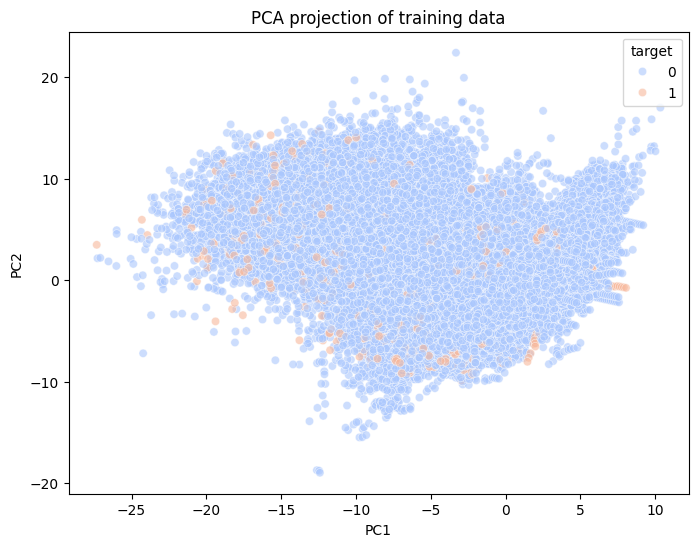

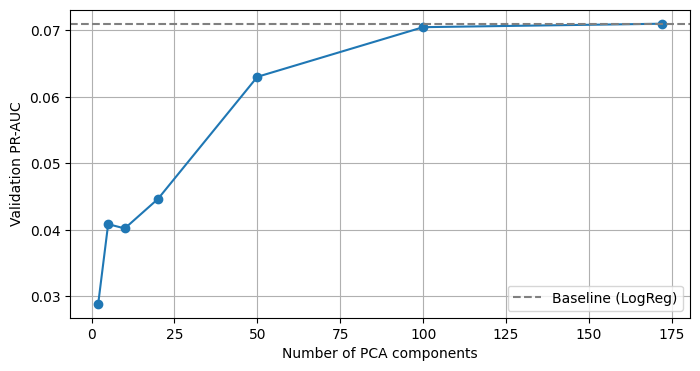

In [ ]:

if 'feature_names' not in dir():
    feature_names = X_train_scaled.columns.tolist() if hasattr(X_train_scaled, 'columns') else [f'feat_{i}' for i in range(X_train_scaled.shape[1])]

if 'baseline_pr_auc' not in dir():
    baseline_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
    baseline_model.fit(X_train_scaled, y_train)
    baseline_preds = baseline_model.predict_proba(X_val_scaled)[:, 1]
    baseline_pr_auc = average_precision_score(y_val, baseline_preds)
    print(f'Baseline PR-AUC = {baseline_pr_auc:.4f}')

pca_2d = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)
df_pca = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca['target'] = np.array(y_train)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='target', alpha=0.6, palette='coolwarm')
plt.title('PCA projection of training data')
plt.show()

pca = PCA(random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

max_n = X_train_scaled.shape[1]
n_components_list = [2, 5, 10, 20, 50, 100, max_n]
pr_aucs = []

for n in n_components_list:
    if n > max_n:
        break
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
    lr.fit(X_train_pca[:, :n], y_train)
    preds = lr.predict_proba(X_val_pca[:, :n])[:, 1]
    pr = average_precision_score(y_val, preds)
    pr_aucs.append(pr)

plt.figure(figsize=(8,4))
plt.plot(n_components_list[:len(pr_aucs)], pr_aucs, marker='o')
plt.axhline(y=baseline_pr_auc, color='gray', linestyle='--', label='Baseline (LogReg)')
plt.xlabel('Number of PCA components')
plt.ylabel('Validation PR-AUC')
plt.legend()
plt.grid(True)
plt.show()

PR-AUC на top-20 признаках: 0.0806


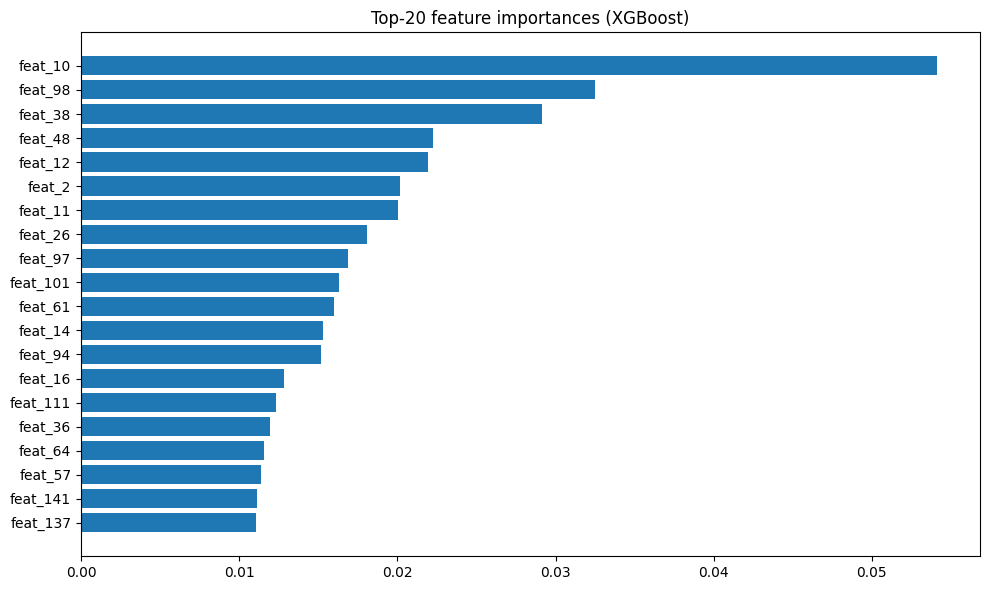

In [47]:
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
top_k = 20
top_features = indices[:top_k]

X_train_top = X_train_scaled[:, top_features]
X_val_top = X_val_scaled[:, top_features]
best_xgb_top = XGBClassifier(**best_xgb_params)
best_xgb_top.fit(X_train_top, y_train)
preds_top = best_xgb_top.predict_proba(X_val_top)[:, 1]
pr_top = average_precision_score(y_val, preds_top)
print(f"PR-AUC на top-{top_k} признаках: {pr_top:.4f}")


plt.figure(figsize=(10,6))
plt.barh(range(top_k), importances[indices[:top_k]][::-1], align='center')
plt.yticks(range(top_k), [feature_names[i] for i in indices[:top_k]][::-1])
plt.title('Top-20 feature importances (XGBoost)')
plt.tight_layout()
plt.show()

# Итог: 

лучшая модель - ансамбль